In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [62]:
list_pos = [str(i.round(1)) for i in np.linspace(1,0,11)]
list_neg = [f'-{i.round(1)}' for i in np.linspace(0.1,1,10)]
list_corr = list_pos+list_neg 

In [57]:
len(list_corr)

21

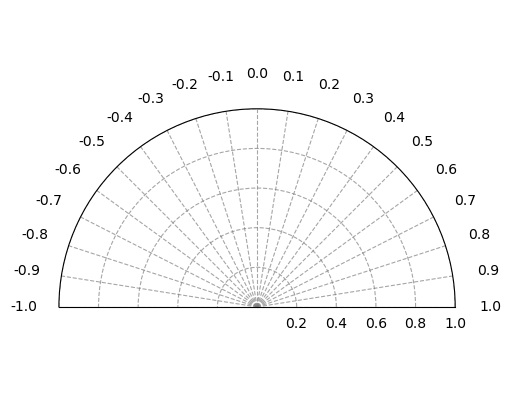

In [146]:
fig, ax = plt.subplots(figsize=(5, 8), subplot_kw={'projection': 'polar'}, layout='constrained')

angles = np.arange(0, 360, 9)
angles = angles[:len(list_corr)]

ax.set_xticks(np.deg2rad(angles))
ax.set_xlim(0, np.pi)
ax.set_xticklabels([f"{val}" for val in list_corr])

r_ticks = [0.2, 0.4, 0.6, 0.8, 1.0]
ax.set_yticks(r_ticks)
ax.set_yticklabels([str(r) for r in r_ticks],fontname='serif')

ax.grid(True, linestyle='--', alpha=0.7,color='gray')
# ax.tick_params(axis='both', which='minor', labelsize=10,color='red')
# Personalizar a aparência dos ticks internos
ax.tick_params(axis='x', which='major', 
               length=6, width=4, color='blue', direction='out',zorder=1)
ax.tick_params(axis='x', which='major', 
               length=15,        # Aumentei o comprimento
               width=4, 
               color='blue', 
               direction='out',
               zorder=3)         # Zorder alto para ficar na frente


In [152]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.grid_finder as gf
import mpl_toolkits.axisartist.floating_axes as fa

In [157]:
tr = PolarAxes.PolarTransform()
rlocs = np.concatenate(((np.arange(11.0) / 10.0), [0.95, 0.99]))
tlocs = np.arccos(rlocs) # Conversion to polar angles
gl1 = gf.FixedLocator(tlocs) # Positions
tf1 = gf.DictFormatter(dict(zip(tlocs, map(str, rlocs))))
# Standard deviation axis extent
# self.smin = 0
# self.smax = 1.5 * self.STD
# gh = fa.GridHelperCurveLinear(tr,extremes=(0,(np.pi/2),self.smin,self.smax),grid_locator1=gl1,tick_formatter1=tf1,)

C:\Users\ferna\AppData\Local\Temp\ipykernel_14196\248693998.py:1: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  tr = PolarAxes.PolarTransform()


TypeError: 'rect' must be an instance of matplotlib.transforms.Bbox or collections.abc.Iterable, not a int

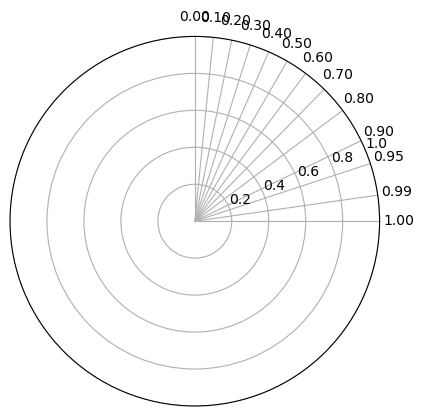

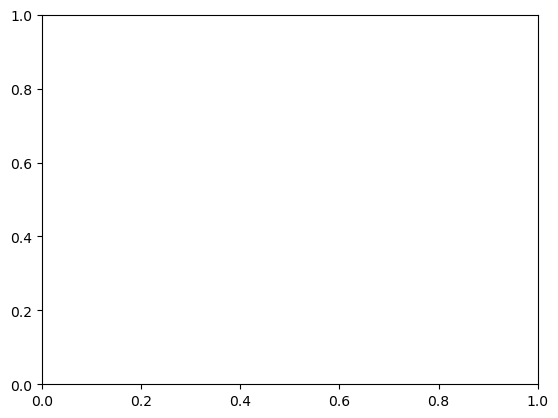

In [169]:
# Versão moderna simplificada
correlation_ticks = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 0.95, 0.99]
angle_ticks = np.arccos(correlation_ticks)

ax = plt.subplot(111, projection='polar')
ax.set_xticks(angle_ticks)
a =ax.set_xticklabels([f'{c:.2f}' for c in correlation_ticks])
std_val = 1
std_min,std_max = 0, 1.5*std_val
gh = fa.GridHelperCurveLinear(
    tr,  # Transformação polar
    extremes=(0, (np.pi/2), std_min, std_max),  # Limites
    grid_locator1=gl1,      # Localizador de ticks angular
    tick_formatter1=tf1,    # Formatador de labels angular
)
fig = plt.subplots()
ax = fa.FloatingSubplot(fig, rect=111, grid_helper=gh)


In [190]:
obsSTD = 0.35
s = [0.33, 0.34, 0.36, 0.38]
r = [0.01, 0.04, 0.81, 0.58]
l = ['A', 'B', 'C', 'D']

fname = 'TaylorDiagram.jpg'


srl(obsSTD, s, r, l, fname)

C:\Users\ferna\AppData\Local\Temp\ipykernel_14196\4241705412.py:4: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  tr = PolarAxes.PolarTransform()
C:\Users\ferna\AppData\Local\Temp\ipykernel_14196\4241705412.py:62: MatplotlibDeprecationWarning: Passing `apply_theta_transforms=True` (the default) is deprecated since Matplotlib 3.9. Support for this will be removed in Matplotlib in 3.11. To prevent this warning, set `apply_theta_transforms=False`, and make sure to shift theta values before being passed to this transform.
  plt.clabel(dia.add_contours(colors='0.5'), inline=1, fontsize=10)


In [10]:
from matplotlib.projections import PolarAxes
import mpl_toolkits.axisartist.grid_finder as gf
import mpl_toolkits.axisartist.floating_axes as fa
from matplotlib.lines import Line2D
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from typing import Union
from matplotlib.font_manager import FontProperties
from warnings import filterwarnings
filterwarnings('ignore')

In [109]:
class TaylorDiagram(object):
    def __init__(self, STD, fig=None, rect=111, label='plot', 
                 color_grid:str='black', linestyle_grid:str='--', 
                 linewidth_grid:float=0.1, grid_alpha:float=0.5,
                 font_family:str='serif', font_size:int=10, 
                 font_weight:str='normal',
                 positive_only:bool=False):
        self.STD = STD
        self.smin = 0.0
        self.smax = 1.5 * self.STD
        self.positive_only = positive_only
                
        tr = PolarAxes.PolarTransform()
        
        if positive_only:
            rlocs = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99, 1.0])
            extremes = (0, np.pi/2, self.smin, self.smax)  # Já está correto!
        else:
            self.smin = -0.01
            positive_rlocs = np.array([0.0, 0.2, 0.4, 0.6, 0.8, 0.9, 0.95, 0.99])
            negative_rlocs = np.array([-0.2, -0.4, -0.6, -0.8, -0.9, -0.95, -0.99, -1.0])
            rlocs = np.concatenate([negative_rlocs, positive_rlocs])
            extremes = (0, np.pi, self.smin, self.smax)
        
        tlocs = np.arccos(rlocs)
        gl1 = gf.FixedLocator(tlocs)
        tf1 = gf.DictFormatter(dict(zip(tlocs, map(str, rlocs))))
        
        gh = fa.GridHelperCurveLinear(
            tr,
            extremes=extremes,
            grid_locator1=gl1,
            tick_formatter1=tf1
        )
        
        if fig is None:
            fig = plt.figure(figsize=(8, 6) if positive_only else (12, 8))  # Tamanho diferente para positive_only
        
        ax = fa.FloatingSubplot(fig, rect, grid_helper=gh)
        fig.add_subplot(ax)
        ax.axis['right'].set_axis_direction('top')
        ax.axis['left'].set_axis_direction('bottom')
        
        if positive_only:
            ax.axis['top'].set_axis_direction('bottom')
            ax.axis['top'].major_ticklabels.set_axis_direction('top')
            ax.axis['top'].toggle(ticklabels=True, label=True)
            ax.axis['bottom'].toggle(ticklabels=False, label=False)
            ax.axis['right'].toggle(ticklabels=False, label=False)
            ax.axis['left'].toggle(ticklabels=True, label=True)
            # CORREÇÃO: Ajustar a posição do subplot para ocupar melhor o espaço
            ax.set_position([0.1, 0.1, 0.7, 0.7])  # [left, bottom, width, height]
        else:
            for kind in ['top','right']: 
                ax.axis[kind].toggle(ticklabels=True, label=True)
            
            ax.axis['right'].set_axis_direction('top')
            ax.axis['left'].set_axis_direction('bottom')
            ax.axis['top'].set_axis_direction('bottom')
            ax.axis['top'].major_ticklabels.set_axis_direction('top')
            ax.axis['right'].major_ticklabels.set_axis_direction('bottom')

        # Aplicar configurações de fonte
        kinds = ['top', 'bottom', 'right', 'left']
        for kind in kinds:
            ax.axis[kind].major_ticklabels.set_fontname(font_family)
            ax.axis[kind].major_ticklabels.set_fontsize(font_size)
            ax.axis[kind].major_ticklabels.set_fontweight(font_weight)

        ax.grid(color=color_grid, linestyle=linestyle_grid, 
                linewidth=linewidth_grid, alpha=grid_alpha)
        
        self._ax = ax
        self.ax = ax.get_aux_axes(tr)

        l, = self.ax.plot([0], self.STD, 'k*', ls='', ms=8, label=label)
        
        if positive_only:
            t = np.linspace(0, np.pi/2, 200)
        else:
            t = np.linspace(0, np.pi, 200)
            
        r = np.zeros_like(t) + self.STD
        self.ax.plot(t, r, 'k--', label='_')

        self.samplePoints = [l]


    def add_sample(self, STD, r, *args, **kwargs):
        # Garantir que correlações negativas não sejam plotadas se positive_only=True
        if self.positive_only and r < 0:
            print(f"Aviso: Correlação {r} ignorada (positive_only=True)")
            return None
            
        angle = np.arccos(r)
        l, = self.ax.plot(angle, STD, *args, **kwargs)
        self.samplePoints.append(l)
        return l

    def add_contours(self, levels=5, **kwargs):
        # Ajustar a malha para positive_only
        if self.positive_only:
            ts = np.linspace(0, np.pi/2, 100)  # 0 a 90°
        else:
            ts = np.linspace(0, np.pi, 100)    # 0 a 180°
            
        rs = np.linspace(self.smin, self.smax, 100)
        RS, TS = np.meshgrid(rs, ts)
        RMSE = np.sqrt(
            np.power(self.STD, 2) + np.power(RS, 2) -
            (2.0 * self.STD * RS * np.cos(TS))
        )
        contours = self.ax.contour(TS, RS, RMSE, levels, **kwargs)
        
        if 'label' in kwargs:    
            proxy = Line2D([0], [0], 
                        linestyle=kwargs.get('linestyle', '--'),
                        color=kwargs.get('colors', kwargs.get('color', 'darkred')), 
                        linewidth=kwargs.get('linewidths', kwargs.get('linewidth', 0.7)),
                        label=kwargs['label'])
            self.samplePoints.append(proxy)
        
        return contours

def params_RMSE(diagram, colors='darkred', linewidths=0.7, label='RMSE', 
                linestyles='--', fontsize=10, inline=True):
    contours = diagram.add_contours(
        colors=colors, 
        linewidths=linewidths, 
        label=label,
        linestyles=linestyles
    )
    if inline:
        plt.clabel(contours, fontsize=fontsize)
    return contours

def PlotTaylorDiagram(obsSTD: Union[list[float], np.ndarray, pd.Series],
         std_val_model: Union[list[float], np.ndarray, pd.Series], 
         r_values: Union[list[float], np.ndarray, pd.Series], 
         name_models: Union[list[str], np.ndarray, pd.Series],
         grid_params: dict = None, 
         font_params: dict = None,
         savefig: bool = False,
         name_fig: str='diagram.png',
         dpi: int=600,
         positive_only: bool =False):
    '''
    obsSTD --> Reference of Standard Value
    std_model --> Standard Value From Model
    r_values --> Correlation Values
    name_models --> Name of Models
    grid_params --> some utils update for visual
    font_params --> some utils update for font types
    '''
    s, r, l = std_val_model, r_values, name_models
    
    # Tamanho de figura diferente para positive_only
    if positive_only:
        fig = plt.figure(figsize=(8, 6))  # Figura menor para apenas 90°
    else:
        fig = plt.figure(figsize=(12, 8))  # Figura maior para 180°
    
    #  Default configuration for grid Params
    default_grid_params = {
        'color_grid': 'gray',
        'linestyle_grid': '-',
        'linewidth_grid': 0.6,
        'grid_alpha': 1
    }

    # Default configuration for font params
    default_font_params = {
        'font_family': 'serif',
        'font_size': 12,
        'font_weight': 'normal'
    }
    
    # Mergin params from user
    if grid_params:
        default_grid_params.update(grid_params)
    if font_params:
        default_font_params.update(font_params)
    
    # Combine params from user
    all_params = {**default_grid_params, **default_font_params}
    all_params['positive_only'] = positive_only
    # Acessing class Taylor Diagram
    diagram = TaylorDiagram(obsSTD, fig=fig, rect=111, label='Observed', **all_params)

    #Utils params From RMSE 
    params_RMSE(diagram=diagram,
    colors='darkred', 
    linewidths=0.8, 
    label='RMSE',
    linestyles='--',
    fontsize=10,
    inline=True)
    
    # Insering the point into graphics 
    cs = plt.matplotlib.cm.Set1(np.linspace(0, 1, len(l)))
    srlc = zip(s, r, l, cs)
    for i in srlc:
        diagram.add_sample(i[0], i[1], label=i[2], c=i[3], marker='s')
    spl = [p.get_label() for p in diagram.samplePoints]
    
    # Legend Params
    fig.legend(
        diagram.samplePoints,
        spl,
        numpoints=1,
        prop=dict(size='medium', 
                 family=default_font_params['font_family'], 
                 weight=default_font_params['font_weight']),
        loc='center left',
        bbox_to_anchor=(0.9, 0.9) # multiple (0.82, 0.8)
    )
    
    plt.tight_layout(pad=0)
    if savefig == True:
        plt.savefig(name_fig, dpi=dpi, bbox_inches='tight')
    return plt.show()

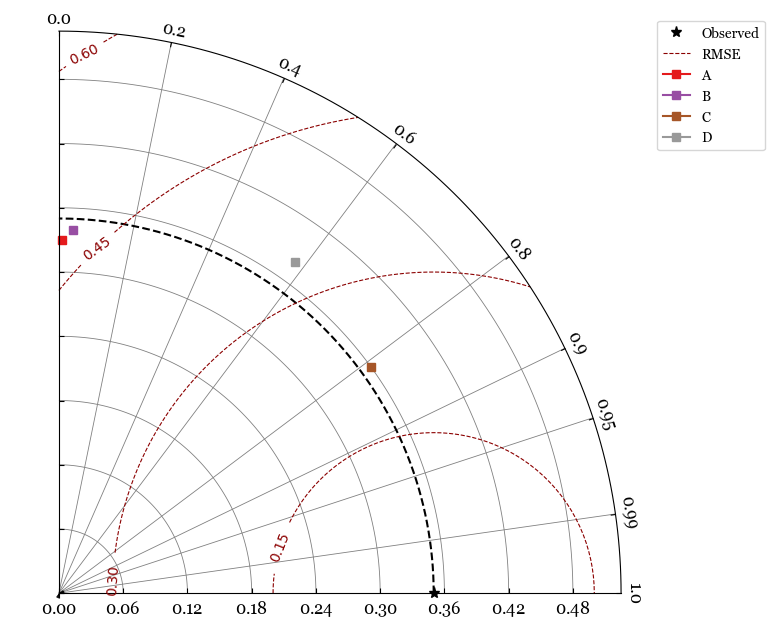

In [ ]:
obsSTD = 0.35
s = [0.33, 0.34, 0.36, 0.38]
r = [0.01, 0.04, 0.81, 0.58]
l = ['A', 'B', 'C', 'D']
fname = 'TaylorDiagram.jpg'

a = PlotTaylorDiagram(obsSTD=obsSTD,
                       std_val_model=s, 
                       r_values=r, 
                       name_models=l,
                       savefig=False,
                       font_params=font_config_2,
                       positive_only=True
                       )

In [ ]:
class TaylorDiagram(object):
    def __init__(self, STD, fig=None, rect=111, label='plot', 
                 color_grid:str='black', linestyle_grid:str='--', 
                 linewidth_grid:float=0.1, grid_alpha:float=0.5,
                 font_family:str='serif', font_size:int=10, font_weight:str='normal',
                 positive_only:bool=False):  # Novo parâmetro
        self.STD = STD
        self.smin = -0.01
        self.smax = 1.5 * self.STD
        self.positive_only = positive_only  # Armazenar a opção
        
        tr = PolarAxes.PolarTransform()
        rlocs = np.concatenate(((-np.arange(11.0) / 10.0)[::-1], 
                              (np.arange(11.0) / 10.0), 
                              [0.95, 0.99, -0.95, -0.99]))
        
        # Filtrar apenas correlações positivas se positive_only=True
        if positive_only:
            rlocs = rlocs[rlocs >= 0]  # Manter apenas correlações >= 0
        
        tlocs = np.arccos(rlocs)
        gl1 = gf.FixedLocator(tlocs)
        tf1 = gf.DictFormatter(dict(zip(tlocs, map(str, rlocs))))
        
        # Ajustar os extremos para positive_only
        if positive_only:
            extremes = (0, np.pi/2, self.smin, self.smax)  # 0 a 90°
        else:
            extremes = (0, np.pi, self.smin, self.smax)    # 0 a 180°
        
        gh = fa.GridHelperCurveLinear(
            tr,
            extremes=extremes,  # Usar extremos condicionais
            grid_locator1=gl1,
            tick_formatter1=tf1
        )
        
        if fig is None:
            fig = plt.figure()
        
        ax = fa.FloatingSubplot(fig, rect, grid_helper=gh)
        fig.add_subplot(ax)

        # Adjustments for ticks and major ticks
        kinds = ['top', 'bottom', 'right', 'left']
        for kind in kinds:
            ax.axis[kind].major_ticklabels.set_fontname(font_family)
            ax.axis[kind].major_ticklabels.set_fontsize(font_size)
            ax.axis[kind].major_ticklabels.set_fontweight(font_weight)
            ax.axis[kind].toggle(ticklabels=True, label=True)
        
        ax.axis['right'].set_axis_direction('top')
        ax.axis['left'].set_axis_direction('bottom')
        ax.axis['top'].set_axis_direction('bottom')
        ax.axis['top'].major_ticklabels.set_axis_direction('top')
        ax.axis['right'].major_ticklabels.set_axis_direction('bottom')

        # Aplicar as configurações de grid
        ax.grid(color=color_grid, linestyle=linestyle_grid, 
                linewidth=linewidth_grid, alpha=grid_alpha)
        
        self._ax = ax
        self.ax = ax.get_aux_axes(tr)

        # reference point + círculo de std
        l, = self.ax.plot([0], self.STD, 'k*', ls='', ms=8, label=label)
        
        # Ajustar o círculo de std para positive_only
        if positive_only:
            t = np.linspace(0, np.pi/2, 200)  # 0 a 90°
        else:
            t = np.linspace(0, np.pi, 200)    # 0 a 180°
            
        r = np.zeros_like(t) + self.STD
        self.ax.plot(t, r, 'k--', label='_')

        self.samplePoints = [l]

    def add_sample(self, STD, r, *args, **kwargs):
        # Garantir que correlações negativas não sejam plotadas se positive_only=True
        if self.positive_only and r < 0:
            print(f"Aviso: Correlação {r} ignorada (positive_only=True)")
            return None
            
        angle = np.arccos(r)
        l, = self.ax.plot(angle, STD, *args, **kwargs)
        self.samplePoints.append(l)
        return l

    def add_contours(self, levels=5, **kwargs):
        # Ajustar a malha para positive_only
        if self.positive_only:
            ts = np.linspace(0, np.pi/2, 100)  # 0 a 90°
        else:
            ts = np.linspace(0, np.pi, 100)    # 0 a 180°
            
        rs = np.linspace(self.smin, self.smax, 100)

        RS, TS = np.meshgrid(rs, ts)

        RMSE = np.sqrt(
            np.power(self.STD, 2) + np.power(RS, 2) -
            (2.0 * self.STD * RS * np.cos(TS))
        )

        contours = self.ax.contour(TS, RS, RMSE, levels, **kwargs)
        
        if 'label' in kwargs:    
            proxy = Line2D([0], [0], 
                          linestyle=kwargs.get('linestyle', '--'),
                          color=kwargs.get('colors', kwargs.get('color', 'darkred')), 
                          linewidth=kwargs.get('linewidths', kwargs.get('linewidth', 0.7)),
                          label=kwargs['label'])
            self.samplePoints.append(proxy)
        
        return contours
    
    def PlotTaylorDiagram(obsSTD, s, r, l, fname, grid_params=None, font_params=None, positive_only=False):
        fig = plt.figure(figsize=(12, 8))
        
        # Configurações padrão do grid
        default_grid_params = {
            'color_grid': 'gray',
            'linestyle_grid': '-',
            'linewidth_grid': 0.6,
            'grid_alpha': 1
        }

        # Configurações padrão de fonte
        default_font_params = {
            'font_family': 'serif',
            'font_size': 12,
            'font_weight': 'normal'
        }
        
        # Mesclar com parâmetros fornecidos pelo usuário
        if grid_params:
            default_grid_params.update(grid_params)
        if font_params:
            default_font_params.update(font_params)
        
        # Combinar todos os parâmetros
        all_params = {**default_grid_params, **default_font_params}
        
        # Adicionar positive_only aos parâmetros
        all_params['positive_only'] = positive_only
        
        diagram = TaylorDiagram(obsSTD, fig=fig, rect=111, label='Observed', **all_params)

        params_RMSE(diagram=diagram,
            colors='darkred', 
            linewidths=0.8, 
            label='RMSE',
            linestyles='--',
            fontsize=10,
            inline=True)
        
        cs = plt.matplotlib.cm.Set1(np.linspace(0, 1, len(l)))
        srlc = zip(s, r, l, cs)

        for i in srlc:
            diagram.add_sample(i[0], i[1], label=i[2], c=i[3], marker='s')

        spl = [p.get_label() for p in diagram.samplePoints]
        
        fig.legend(
            diagram.samplePoints,
            spl,
            numpoints=1,
            prop=dict(size='medium', 
                    family=default_font_params['font_family'], 
                    weight=default_font_params['font_weight']),
            loc='center left',
            bbox_to_anchor=(0.82, 0.8)
        )
        
        plt.tight_layout(pad=0)
        plt.savefig(fname, dpi=600, bbox_inches='tight')
        
        return plt.show()

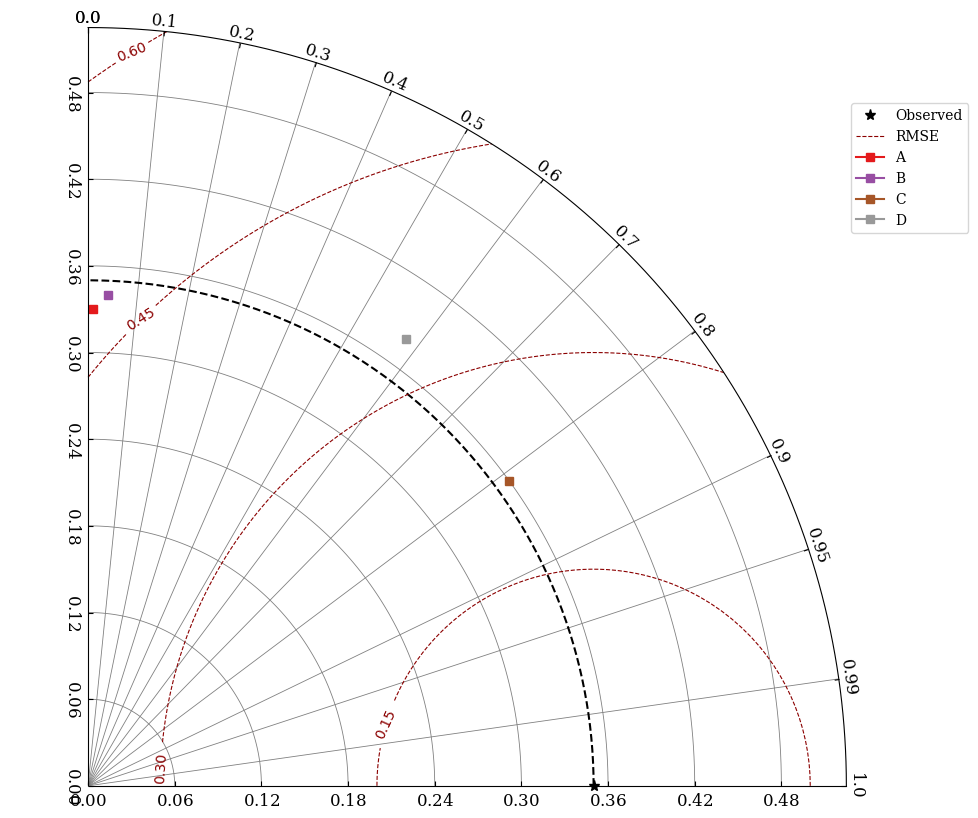

In [500]:
# Para mostrar apenas correlações positivas (0-90°)
a = srl(obsSTD, s, r, l, fname, positive_only=True)

# Para mostrar todas as correlações (0-180°) - padrão
# a = srl(obsSTD, s, r, l, fname, positive_only=False)